# OUTLIER DETECTION:

## DEFINITION:

Outlier detection is the process of identifying data points that are significantly different from the normal pattern of the dataset.

 It finds unusual or abnormal data points that do not fit the general pattern.

## What are OUTLIERS?

### DEFINITION:

Outliers are data points that are significantly different from the normal pattern of the other data points in a dataset.

An outlier is an unusual value that is far away from most of the other values.

#### Real time Examples:

* Manufacturing: Find defective products from sensor readings.
* Cybersecurity: Detect unusual network activity.
* E-commerce: Identify unusual purchasing behavior.

#### EXAMPLE:

Patient Visits : 3, 11, 89, 15, 23, 27, 13, 62, 92, 12, 47, 61, 34, 88

Here, 92 is much higher than the other Patients Visits, so it is an outlier.

In [6]:
import pandas as pd
patient_visits = (3, 11, 89, 15, 23, 27, 13, 62, 92, 12, 47, 61, 34, 88)
data = pd.DataFrame({"PATIENT VISITS": patient_visits})
print (data)

    PATIENT VISITS
0                3
1               11
2               89
3               15
4               23
5               27
6               13
7               62
8               92
9               12
10              47
11              61
12              34
13              88


## TYPES OF OUTLIERS:

### DEFINITION:

Outliers can be classified based on how and why they differ from normal data. The three common types are:

### 1.  Global Outlier: 
A global outlier is a data point that is significantly different from the entire dataset.

#### Example:

10, 12, 11, 13, 15, 14, 100

Here, 100 is a global outlier because it is far away from all the other values.

##### Real-life use:
In banking, a transaction of ₹5,00,000 may be a global outlier if a customer's normal transactions are around ₹1,000–₹5,000.

### 2. Contextual Outlier
A contextual outlier is a data point that is unusual within a particular context, but may be normal in another context.

#### Example:

Temperature = 35°C

35°C may be normal during summer, but unusual during winter.

##### Real-life use:
In weather monitoring, a temperature of 35°C in summer may be normal, while 35°C in winter could be considered an outlier.



### 3. Collective Outlier
A collective outlier occurs when a group of data points together forms an unusual pattern, even though individual points may appear normal.

#### Example:

Normal network traffic:
20, 22, 21, 23, 22

Unusual pattern:
80, 82, 85, 81, 83

Each value in the second group might not look extremely unusual individually, but the group together represents abnormal network activity.

##### Real-life use:
In cybersecurity, a sequence of many unusual login attempts within a short period can indicate a cyberattack.

## DETECTING OUTLIERS:

### DEFINITION:

Detecting outliers is the process of finding data points that are significantly different from the normal pattern of a dataset.

In AI/ML, outliers can be detected using statistical methods, distance-based methods, or machine-learning algorithms.

It means finding unusual or abnormal data points in a dataset.

#### Real time Examples:

* Banking: Detect unusual transactions for fraud detection.
* Healthcare: Identify abnormal heart rate or blood pressure measurements.
* Cybersecurity: Detect unusual network behavior.

#### Methods include:

1. IQR Method
2. Z-Score Method
3. Box Plot
4. Scatter Plot

## IQR METHOD:

### DEFINITION:

IQR (Interquartile Range) method is a statistical technique used to detect outliers by examining the middle 50% of the data.

### FORMULA:

The IQR is calculated as:

IQR = Q3 - Q1

Where:

Q1 (First Quartile) → 25th percentile

Q3 (Third Quartile) → 75th percentile

The outlier boundaries are:

Lower Bound = Q1 - 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR

Any value below the lower bound or above the upper bound is considered an outlier.

#### Real time Examples:

The IQR method is useful for:

* Banking: Detect unusually large transactions.
* Healthcare: Find abnormal patient measurements.

#### EXAMPLE:
Suppose a food-delivery company records delivery times in minutes:

20, 22, 24, 25, 26, 27, 28, 30, 90

Most deliveries take around 20–30 minutes, but 90 minutes is unusually high.

In [12]:
import numpy as np

delivery_time = [20, 22, 24, 25, 26, 27, 28, 30, 90]

Q1 = np.percentile(delivery_time, 25)
Q3 = np.percentile(delivery_time, 75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = [
    x for x in delivery_time
    if x < lower or x > upper
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Outliers:", outliers)


Q1: 24.0
Q3: 28.0
IQR: 4.0
Outliers: [90]


##### Code Explanation:
The IQR method is an outlier-detection technique that identifies values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR, where IQR = Q3 − Q1.

## Z-SCORE METHOD:

### DEFINITION:

The Z-score method is a statistical technique used to detect outliers by measuring how many standard deviations a data point is away from the mean.

### FORMULA:

The formula is:

                                             Z=(x−μ)/σ

Where:

x = data point

μ = mean of the dataset

σ = standard deviation

A common rule is:

If |Z| > 3, the value is considered an outlier.

In simple words, the Z-score tells us how far a value is from the average.

##### Real time Examples:

* Banking: Detect unusually large transactions.
* Healthcare: Identify abnormal patient measurements.

#### EXAMPLE:

In [16]:
from scipy.stats import zscore

scores = [50, 55, 60, 62, 65, 68, 70, 72, 150]

z_scores = zscore(scores)

outliers = [
    score for score, z in zip(scores, z_scores)
    if abs(z) > 3
]

print("Outliers:", outliers)


Outliers: []


##### Code Explanation:
That does not mean 150 is normal—it means the simple Z-score rule is not sensitive enough for this tiny dataset.

## BOX PLOT:

### DEFINITION:

A Box Plot is a graphical method used to visualize the distribution of numerical data and identify possible outliers.

It displays:

Q1 – First quartile

Median – Middle value

Q3 – Third quartile

Whiskers – Normal data range

Points outside the whiskers – Possible outliers

### EXAMPLE:


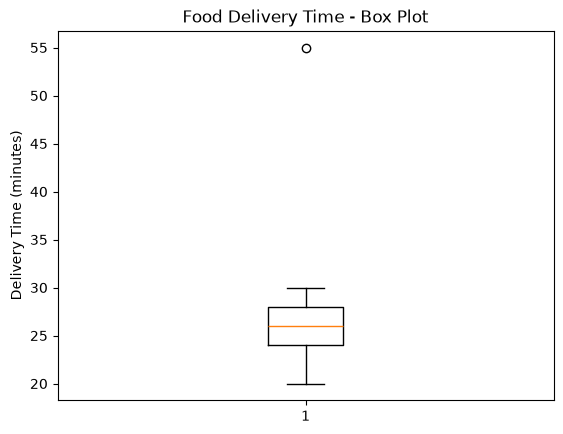

In [17]:
import matplotlib.pyplot as plt

delivery_time = [20, 22, 24, 25, 26, 27, 28, 30, 55]

plt.boxplot(delivery_time)
plt.ylabel("Delivery Time (minutes)")
plt.title("Food Delivery Time - Box Plot")
plt.show()


##### Code Explanation:
The 55-minute delivery appears separately from the main distribution, making it easy to identify as a possible outlier.
A box plot is a graphical method that summarizes the distribution of data using quartiles and helps identify possible outliers that lie beyond the whiskers.

## SCATTER PLOT:

### DEFINITION:

A scatter plot is a graphical method that uses points to show the relationship between two numerical variables.

In outlier detection, a scatter plot helps us visually identify data points that are far away from the main group of points.

In simple words: A scatter plot helps us see the normal pattern and unusual points (outliers) in data.

#### Real time Examples:

* Manufacturing: Detect abnormal machine readings.
* Education: Find students whose study time and marks are unusual.

#### EXAMPLE:

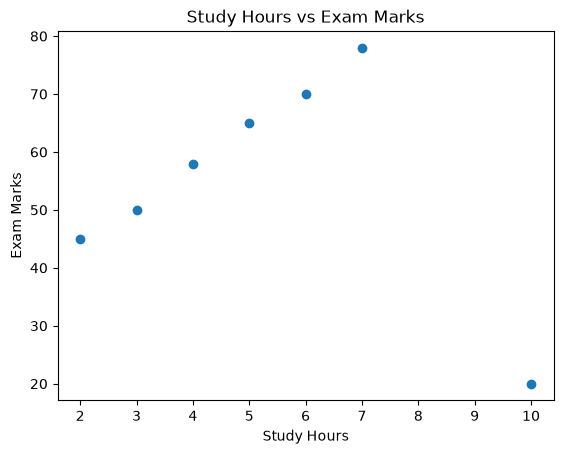

In [18]:
import matplotlib.pyplot as plt

hours = [2, 3, 4, 5, 6, 7, 10]
marks = [45, 50, 58, 65, 70, 78, 20]

plt.scatter(hours, marks)

plt.xlabel("Study Hours")
plt.ylabel("Exam Marks")
plt.title("Study Hours vs Exam Marks")

plt.show()


##### Code Explanation:
The point (10, 20) is far away from the general pattern, so it can be investigated as a possible outlier.